In [1]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, QuantumRegister, transpile
from qiskit.circuit.library import RYGate
from qiskit_aer import AerSimulator
from shift_operators import ShiftDown, ShiftUp

In [76]:
n = 3
k = int(np.ceil(np.log2(n)))
theta = 2 * np.arcsin(1 / np.sqrt(n))

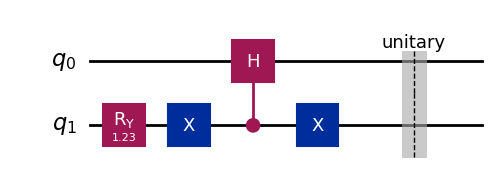

In [79]:
simulator = AerSimulator(method="unitary")
qc = QuantumCircuit(k)

qc.ry(theta, 1)
qc.x(1)
qc.ch(1, 0)
qc.x(1)
qc.save_unitary()
qc.draw(output="mpl")


In [80]:
qc = transpile(qc, simulator)

result = simulator.run(qc).result()
unitary = result.get_unitary(qc).data.real
unitary

array([[ 5.77350269e-01,  5.77350269e-01, -4.08248290e-01,
        -4.08248290e-01],
       [ 5.77350269e-01, -5.77350269e-01, -4.08248290e-01,
         4.08248290e-01],
       [ 5.77350269e-01, -1.76762540e-17,  8.16496581e-01,
        -1.94828431e-17],
       [ 7.31874052e-17,  5.77350269e-01,  1.30505146e-16,
         8.16496581e-01]])

In [81]:
psi = np.array([[1], *[[0]] * 3])

In [82]:
unitary @ psi

array([[5.77350269e-01],
       [5.77350269e-01],
       [5.77350269e-01],
       [7.31874052e-17]])

In [ ]:
def equal_superposition(k, nq=None):
    """Creates a quantum circuit that creates an equal superposition between |0> and |k-1>."""
    if nq is None:
        nq = int(np.ceil(np.log2(k)))

    qc = QuantumCircuit(nq)

    if k == 1:
        return qc
    
    elif (k & (k - 1)) == 0:
        qc.h(range(int(np.log2(k))))

        return qc
    
    n_extra_states = k - 2 ** (nq-1)
    theta = 2 * np.arcsin(np.sqrt(n_extra_states / k))

    qc.ry(theta, nq-1)
    qc.x(nq-1)
    qc.ch(nq-1, range(nq-1))
    qc.x(nq-1)

    circuit = equal_superposition(n_extra_states, nq-1)
    gate = circuit.to_gate().control(1)
    qc.append(gate, [nq-1] + list(range(nq-1)))

    return qc

In [248]:
qc = equal_superposition(5)
qc.draw()

k = 1
     
q_0: 
     
q_1: 
     


┌───┐          ┌──────────────┐
q_0: ───────────────────┤ H ├──────────┤0             ├
                        └─┬─┘┌───┐     │  circuit-632 │
q_1: ─────────────────────┼──┤ H ├─────┤1             ├
     ┌────────────┐┌───┐  │  └─┬─┘┌───┐└──────┬───────┘
q_2: ┤ Ry(0.9273) ├┤ X ├──■────■──┤ X ├───────■────────
     └────────────┘└───┘          └───┘

In [256]:
qc = equal_superposition(8)
qc.save_unitary()
qc = transpile(qc, simulator)

result = simulator.run(qc).result()
unitary = result.get_unitary(qc).data.real

psi = np.zeros((2 ** int(np.ceil(np.log2(k))), 1))
psi[0, 0] = 1

np.round(unitary @ psi, 4)

k is power of 2
k = 3


array([[0.3536],
       [0.3536],
       [0.3536],
       [0.3536],
       [0.3536],
       [0.3536],
       [0.3536],
       [0.3536]])

In [131]:
0.2887 ** 2

0.08334769

In [132]:
1 /np.sqrt(6)

np.float64(0.4082482904638631)

In [190]:
qc = QuantumCircuit(2)
qc.x(0)
qc.draw()
gate = qc.to_gate()

In [193]:
qc = QuantumCircuit(2)
qc.append(gate, [1, 0])

In [194]:
qc.draw()

┌──────────────┐
q_0: ┤1             ├
     │  circuit-283 │
q_1: ┤0             ├
     └──────────────┘